# AOI-based, date- and cloud-filtered Sentinel-2 L1C queue for FORCE

This notebook prepares the Sentinel-2 Level-1C inputs for a later FORCE Level-2 run. It:

1. selects all Sentinel-2 MGRS tiles intersecting a freely chosen AOI (needs to be a gpkg in EPSG 4326),
2. searches only those tile folders in the Terrabyte L1C archive,
3. filters products by acquisition date, sensor and maximum product-level cloud cover, and
4. writes a FORCE-compatible queue, that can be ingested in the L2 processing pipeline.


In [1]:
from pathlib import Path
import os
import re
import zipfile
from datetime import datetime
import xml.etree.ElementTree as ET

import geopandas as gpd
import pandas as pd
from IPython.display import display


## 1. Configuration

For normal use, edit only this cell: AOI, dates and cloud cover threshold


In [10]:
# =====================================================================
# USER SETTINGS
# =====================================================================

# ---------------------------------------------------------------------
# 1. Spatial selection
# ---------------------------------------------------------------------
# The AOI may use any correctly defined CRS. It is transformed only
# temporarily to the MGRS-grid CRS for the spatial intersection.
AOI_GPKG = Path("/mnt/dss_ce/AOI/test.gpkg")
AOI_LAYER = "t"                 # can also be NONE, then the first layer is used

# Official Sentinel-2 MGRS grid, retained in WGS84 / EPSG:4326.
S2_TILE_GRID_GPKG = Path(
    "/mnt/dss_ce/GIS/"
    "sentinel2_mgrs_tile_grid.gpkg"
)
S2_TILE_GRID_LAYER = "sentinel2grid_land"
S2_TILE_FIELD = "tile"
EXPECT_TILE_GRID_WGS84 = True

# ---------------------------------------------------------------------
# 2. Temporal and cloud-cover selection
# ---------------------------------------------------------------------
START_DATE = "2026-01-01"        # inclusive; format YYYY-MM-DD
END_DATE   = "2026-06-30"        # inclusive; format YYYY-MM-DD
MAX_CLOUD_COVER = 80.0           # product-level cloud cover, 0-100 %

# Accepted Sentinel-2 platforms.
ALLOWED_SENSORS = ("S2A", "S2B", "S2C")

# Products without readable cloud metadata cannot be tested against the
# threshold and are therefore excluded by default.
INCLUDE_PRODUCTS_WITHOUT_CLOUD_METADATA = False

# Optional limits for a small test. Keep None for a complete run.
MAX_PRODUCTS_PER_TILE = None
MAX_PRODUCTS_TOTAL = None

# ---------------------------------------------------------------------
# 3. Sentinel-2 L1C archive on Terrabyte DSS
# ---------------------------------------------------------------------
# Confirmed archive structure:
#   tiles/<UTM zone>/<latitude band>/<100-km square>/<year>/<month>/<product>.SAFE
# Example:
#   tiles/01/J/CG/2026/03/S2C_MSIL1C_..._T01JCG_....SAFE
S2_L1C_TILES = Path(
    "/mnt/terrabyte_dss/Sentinel-2-Col-1/L1C/tiles"
)

# ---------------------------------------------------------------------
# 4. Outputs
# ---------------------------------------------------------------------

BASE = Path("/mnt/dss_ce")

DIR_AOI = BASE / "AOI"
DIR_L1 = BASE / "L1"
DIR_PROV = BASE / "PROV"

# Create only the required subdirectories.
# The mounted base directory /mnt/dss_ce itself is assumed to exist.
for directory in [DIR_AOI, DIR_L1, DIR_PROV]:
    directory.mkdir(parents=True, exist_ok=True)

# Plain-text list of the selected Sentinel-2 MGRS tile IDs
TILE_POOL_TXT = DIR_PROV / "selected_s2_tiles.txt"

# Spatial output containing the selected Sentinel-2 tile polygons
SELECTED_TILES_GPKG = DIR_PROV / "selected_s2_tiles.gpkg"

# CSV manifest containing all Sentinel-2 products that passed the filters
MANIFEST_CSV = DIR_PROV / "selected_s2_l1c_products.csv"

# FORCE Level-1 pool file stored directly in the L1 directory
QUEUE_FILE = DIR_L1 / "l1_pool_S2.txt"

# Directory for provenance information and downloaded metadata
METADATA_DIR = DIR_PROV / "metadata"
METADATA_DIR.mkdir(parents=True, exist_ok=True)

print("Base directory:      ", BASE)
print("AOI directory:       ", DIR_AOI)
print("L1 directory:        ", DIR_L1)
print("PROV directory:      ", DIR_PROV)
print("Selected tiles TXT:  ", TILE_POOL_TXT)
print("Selected tiles GPKG: ", SELECTED_TILES_GPKG)
print("Product manifest:    ", MANIFEST_CSV)
print("Queue file:          ", QUEUE_FILE)
print("Metadata directory:  ", METADATA_DIR)

Base directory:       /mnt/dss_ce
AOI directory:        /mnt/dss_ce/AOI
L1 directory:         /mnt/dss_ce/L1
PROV directory:       /mnt/dss_ce/PROV
Selected tiles TXT:   /mnt/dss_ce/PROV/selected_s2_tiles.txt
Selected tiles GPKG:  /mnt/dss_ce/PROV/selected_s2_tiles.gpkg
Product manifest:     /mnt/dss_ce/PROV/selected_s2_l1c_products.csv
Queue file:           /mnt/dss_ce/L1/l1_pool_S2.txt
Metadata directory:   /mnt/dss_ce/PROV/metadata


## 2. Validate configuration

This cell checks dates, thresholds, vector inputs and the resolved Terrabyte archive path before any archive search begins.


In [11]:
def parse_iso_date(value: str):
    """Parse YYYY-MM-DD and return a date object."""
    return datetime.strptime(value, "%Y-%m-%d").date()


def validate_configuration():
    start = parse_iso_date(START_DATE)
    end = parse_iso_date(END_DATE)

    if start > end:
        raise ValueError("START_DATE must not be later than END_DATE.")
    if not 0 <= float(MAX_CLOUD_COVER) <= 100:
        raise ValueError("MAX_CLOUD_COVER must be between 0 and 100.")
    if not AOI_GPKG.exists():
        raise FileNotFoundError(f"AOI GeoPackage not found: {AOI_GPKG}")
    if not S2_TILE_GRID_GPKG.exists():
        raise FileNotFoundError(
            "Sentinel-2 tile-grid GeoPackage not found: "
            f"{S2_TILE_GRID_GPKG}"
        )
    if not S2_L1C_TILES.exists():
        raise FileNotFoundError(
            "Sentinel-2 L1C archive not found at the configured path: "
            f"{S2_L1C_TILES}"
        )

    return start, end


START, END = validate_configuration()
print("Configuration is valid.")

Configuration is valid.


## 3. Select Sentinel-2 tiles intersecting the AOI

The MGRS grid stays in WGS84. The AOI is transformed only temporarily to the grid CRS. The persistent text output contains normalized tile IDs such as `T32UPU`.


In [12]:
TILE_ID_RE = re.compile(r"(?:^|[^0-9A-Z])T?(\d{2}[A-Z]{3})(?:$|[^0-9A-Z])")


def read_vector(path: Path, layer=None):
    """Read a vector layer and retain only valid, non-empty geometries."""
    kwargs = {"layer": layer} if layer is not None else {}
    gdf = gpd.read_file(path, **kwargs)

    if gdf.empty:
        raise ValueError(f"Vector layer contains no features: {path}")
    if gdf.crs is None:
        raise ValueError(f"Vector layer has no CRS: {path}")

    gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].copy()
    try:
        gdf.geometry = gdf.geometry.make_valid()
    except AttributeError:
        # Older GeoPandas/Shapely versions may not provide make_valid().
        gdf.geometry = gdf.geometry.buffer(0)

    if gdf.empty:
        raise ValueError(f"No usable geometries remain in: {path}")
    return gdf


def normalize_s2_tile_id(value):
    """Convert values such as '32UPU' or 'T32UPU' to 'T32UPU'."""
    if pd.isna(value):
        return None
    text = str(value).strip().upper()
    match = TILE_ID_RE.search(text)
    return f"T{match.group(1)}" if match else None


def detect_tile_field(tiles: gpd.GeoDataFrame):
    """Find the attribute column that most consistently contains MGRS tile IDs."""
    preferred = [
        "tile_id", "TILE_ID", "s2_tile", "S2_TILE", "mgrs_tile",
        "MGRS_TILE", "name", "Name", "NAME", "tile", "TILE"
    ]
    columns = [c for c in tiles.columns if c != tiles.geometry.name]
    ordered = [c for c in preferred if c in columns] + [
        c for c in columns if c not in preferred
    ]

    scores = {}
    for column in ordered:
        sample = tiles[column].dropna().head(2000)
        if sample.empty:
            scores[column] = 0.0
        else:
            scores[column] = sample.map(normalize_s2_tile_id).notna().mean()

    best = max(scores, key=scores.get, default=None)
    if best is None or scores[best] < 0.5:
        raise ValueError(
            "Could not detect a Sentinel-2 tile-ID field automatically. "
            "Set S2_TILE_FIELD explicitly in the configuration cell."
        )

    print(
        f"Automatically detected tile field: {best!r} "
        f"(match rate {scores[best]:.1%})"
    )
    return best


# ---------------------------------------------------------------------
# Read the original AOI and the unchanged Sentinel-2 MGRS grid.
# ---------------------------------------------------------------------
aoi = read_vector(AOI_GPKG, AOI_LAYER)
tiles = read_vector(S2_TILE_GRID_GPKG, S2_TILE_GRID_LAYER)

print(f"Original AOI CRS: {aoi.crs}")
print(f"MGRS-grid CRS:    {tiles.crs}")

# The official KML/GPKG grid is expected to be WGS84. Do not silently
# assign EPSG:4326 if the CRS is missing; read_vector() already rejects
# layers without CRS information.
grid_epsg = tiles.crs.to_epsg()
if EXPECT_TILE_GRID_WGS84 and grid_epsg != 4326:
    print(
        "WARNING: The MGRS grid is not identified as EPSG:4326 "
        f"(reported CRS: {tiles.crs}). The grid will remain unchanged, "
        "and the AOI will be transformed to this reported CRS."
    )

tile_field = S2_TILE_FIELD or detect_tile_field(tiles)
if tile_field not in tiles.columns:
    raise KeyError(
        f"S2_TILE_FIELD {tile_field!r} is not present in the tile grid."
    )

# ---------------------------------------------------------------------
# Create a temporary AOI copy in the grid CRS.
#
# Important:
# - 'aoi' remains in its original CRS.
# - 'tiles' remains in its original CRS, normally EPSG:4326.
# - only 'aoi_for_tile_selection' is transformed.
# ---------------------------------------------------------------------
if aoi.crs == tiles.crs:
    aoi_for_tile_selection = aoi.copy()
else:
    aoi_for_tile_selection = aoi.to_crs(tiles.crs)

try:
    aoi_geometry = aoi_for_tile_selection.geometry.union_all()
except AttributeError:
    aoi_geometry = aoi_for_tile_selection.geometry.unary_union

# Spatially retain only MGRS polygons intersecting the AOI.
selected_tiles = tiles.loc[
    tiles.geometry.intersects(aoi_geometry)
].copy()

selected_tiles["s2_tile_id"] = selected_tiles[tile_field].map(
    normalize_s2_tile_id
)
selected_tiles = selected_tiles.dropna(subset=["s2_tile_id"])
selected_tiles = (
    selected_tiles
    .drop_duplicates(subset=["s2_tile_id"])
    .sort_values("s2_tile_id")
)

if selected_tiles.empty:
    raise RuntimeError(
        "The AOI does not intersect any valid Sentinel-2 tiles. "
        "Check both CRS definitions and the layer extents."
    )

S2_TILE_IDS = selected_tiles["s2_tile_id"].tolist()

# Save the spatial and plain-text tile pools for inspection and reuse.
# The output polygons retain the MGRS-grid CRS, normally EPSG:4326.
TILE_POOL_TXT.write_text(
    "\n".join(S2_TILE_IDS) + "\n",
    encoding="utf-8",
)

if SELECTED_TILES_GPKG.exists():
    SELECTED_TILES_GPKG.unlink()

selected_tiles[["s2_tile_id", "geometry"]].to_file(
    SELECTED_TILES_GPKG,
    layer="intersecting_s2_tiles",
    driver="GPKG",
)

print(f"Temporary selection CRS: {aoi_for_tile_selection.crs}")
print(f"Selected-tile CRS:       {selected_tiles.crs}")
print(f"Selected {len(S2_TILE_IDS)} Sentinel-2 tile(s):")
print(", ".join(S2_TILE_IDS))
print("Tile pool:       ", TILE_POOL_TXT)
print("Tile geometries: ", SELECTED_TILES_GPKG)


Original AOI CRS: EPSG:4326
MGRS-grid CRS:    EPSG:4326
Temporary selection CRS: EPSG:4326
Selected-tile CRS:       EPSG:4326
Selected 6 Sentinel-2 tile(s):
T32UPU, T32UPV, T32UQU, T32UQV, T33UUP, T33UUQ
Tile pool:        /mnt/dss_ce/PROV/selected_s2_tiles.txt
Tile geometries:  /mnt/dss_ce/PROV/selected_s2_tiles.gpkg


### Optional visual check

This diagnostic map shows the temporary AOI copy and the selected MGRS tiles. It does not modify either source dataset.


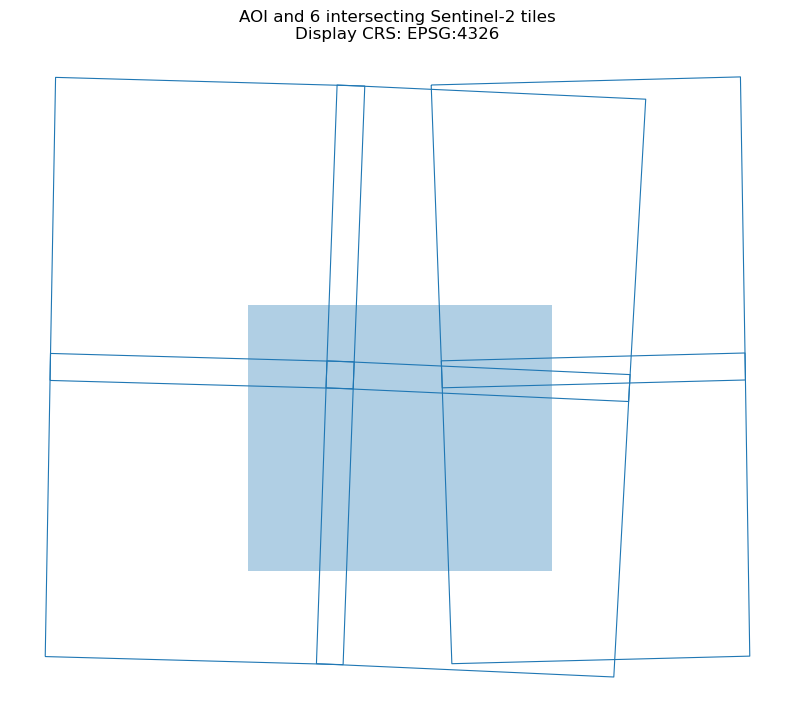

In [13]:
ax = selected_tiles.boundary.plot(figsize=(10, 10), linewidth=0.8)
aoi_for_tile_selection.plot(ax=ax, alpha=0.35)
ax.set_title(
    f"AOI and {len(selected_tiles)} intersecting Sentinel-2 tiles\n"
    f"Display CRS: {selected_tiles.crs}"
)
ax.set_axis_off()


## 4. Locate and filter Sentinel-2 L1C products

Only archive folders belonging to the selected MGRS tiles are searched. Within each tile, the notebook opens only the year/month folders overlapping the requested period, following the confirmed Terrabyte structure:

`tiles/<zone>/<band>/<square>/<year>/<month>/<product>.SAFE`

Product names are filtered by sensor, tile and acquisition date. Product-level cloud cover is read from `MTD_MSIL1C.xml`. SAFE internals such as `GRANULE/.../IMG_DATA` are not traversed.


In [14]:
PRODUCT_RE = re.compile(
    r"(?P<sensor>S2[ABC])_MSIL1C_(?P<date>\d{8})T\d{6}.*_T(?P<tile>\d{2}[A-Z]{3})_"
)


def parse_product_name(path: Path):
    """Extract platform, acquisition date, and MGRS tile from a product name."""
    match = PRODUCT_RE.search(path.name.upper())
    if not match:
        return None
    return {
        "sensor": match.group("sensor"),
        "date": datetime.strptime(match.group("date"), "%Y%m%d").date(),
        "tile": "T" + match.group("tile"),
    }


def dss_tile_directory(root: Path, tile_id: str):
    """Translate T32UPU to the DSS hierarchy 32/U/PU."""
    tile = tile_id[1:] if tile_id.startswith("T") else tile_id
    if not re.fullmatch(r"\d{2}[A-Z]{3}", tile):
        raise ValueError(f"Invalid Sentinel-2 tile ID: {tile_id}")
    return root / tile[:2] / tile[2] / tile[3:]


def iter_month_directories(tile_root: Path, start_date, end_date):
    """Yield only year/month folders overlapping the requested period."""
    months = pd.period_range(
        start=pd.Timestamp(start_date),
        end=pd.Timestamp(end_date),
        freq="M",
    )

    for month in months:
        month_dir = tile_root / f"{month.year:04d}" / f"{month.month:02d}"
        if month_dir.exists():
            yield month_dir


def iter_l1c_candidates(tile_root: Path, start_date, end_date):
    """
    Yield L1C SAFE directories and ZIP files from relevant year/month folders.

    Terrabyte structure:
      <tile>/<year>/<month>/<S2*_MSIL1C_...>.SAFE

    SAFE products are yielded as complete inputs; their internal GRANULE and
    IMG_DATA directories are deliberately not traversed.
    """
    if not tile_root.exists():
        return

    for month_dir in iter_month_directories(tile_root, start_date, end_date):
        for dirpath, dirnames, filenames in os.walk(month_dir):
            current = Path(dirpath)

            safe_names = [
                name for name in dirnames
                if name.upper().endswith(".SAFE") and "MSIL1C" in name.upper()
            ]
            for name in safe_names:
                yield current / name

            # Do not descend into SAFE products such as GRANULE/.../IMG_DATA.
            dirnames[:] = [name for name in dirnames if name not in safe_names]

            for name in filenames:
                upper_name = name.upper()
                if upper_name.endswith(".ZIP") and "MSIL1C" in upper_name:
                    yield current / name


def xml_local_name(tag: str):
    return tag.rsplit("}", 1)[-1]


def cloud_cover_from_xml(xml_content: bytes):
    """Read product cloud cover from Sentinel-2 L1C metadata XML."""
    root = ET.fromstring(xml_content)
    accepted_tags = {
        "Cloud_Coverage_Assessment",
        "CLOUDY_PIXEL_PERCENTAGE",
    }
    for element in root.iter():
        if xml_local_name(element.tag) in accepted_tags and element.text:
            try:
                return float(element.text.strip())
            except ValueError:
                continue
    return None


def read_product_cloud_cover(product: Path):
    """Read cloud cover from an extracted SAFE product or a ZIP archive."""
    try:
        if product.is_dir() and product.name.endswith(".SAFE"):
            metadata = product / "MTD_MSIL1C.xml"
            if metadata.exists():
                return cloud_cover_from_xml(metadata.read_bytes())
            return None

        if product.is_file() and product.suffix.lower() == ".zip":
            with zipfile.ZipFile(product) as archive:
                members = [
                    name for name in archive.namelist()
                    if name.endswith("/MTD_MSIL1C.xml") or name == "MTD_MSIL1C.xml"
                ]
                if not members:
                    return None
                with archive.open(members[0]) as stream:
                    return cloud_cover_from_xml(stream.read())
    except (OSError, zipfile.BadZipFile, ET.ParseError) as exc:
        print(f"WARNING: could not read cloud metadata for {product}: {exc}")
    return None


def product_identity(path: Path):
    """Return a stable key so duplicate SAFE/ZIP representations are queued once."""
    name = path.name
    for suffix in (".SAFE", ".zip", ".ZIP"):
        if name.endswith(suffix):
            return name[:-len(suffix)]
    return name


def collect_products(tile_ids):
    records = []
    missing_tile_dirs = []

    for tile_id in tile_ids:
        tile_root = dss_tile_directory(S2_L1C_TILES, tile_id)
        if not tile_root.exists():
            missing_tile_dirs.append((tile_id, tile_root))
            continue

        tile_records = []
        seen = set()

        for product in iter_l1c_candidates(tile_root, START, END):
            metadata = parse_product_name(product)
            if metadata is None:
                continue
            if metadata["sensor"] not in ALLOWED_SENSORS:
                continue
            if metadata["tile"] != tile_id:
                continue
            if not START <= metadata["date"] <= END:
                continue

            identity = product_identity(product)
            if identity in seen:
                continue
            seen.add(identity)

            cloud_cover = read_product_cloud_cover(product)
            cloud_is_known = cloud_cover is not None
            cloud_is_acceptable = cloud_is_known and cloud_cover <= MAX_CLOUD_COVER

            if not cloud_is_acceptable:
                if not (cloud_cover is None and INCLUDE_PRODUCTS_WITHOUT_CLOUD_METADATA):
                    continue

            tile_records.append({
                "sensor": metadata["sensor"],
                "date": metadata["date"].isoformat(),
                "tile": tile_id,
                "cloud_cover_percent": cloud_cover,
                "path": str(product),
                "input_type": "SAFE" if product.is_dir() else "ZIP",
            })

        tile_records.sort(key=lambda item: (item["date"], item["path"]))
        if MAX_PRODUCTS_PER_TILE is not None:
            tile_records = tile_records[:int(MAX_PRODUCTS_PER_TILE)]
        records.extend(tile_records)

    if missing_tile_dirs:
        print("WARNING: no DSS directory found for these selected tiles:")
        for tile_id, tile_root in missing_tile_dirs:
            print(f"  {tile_id}: {tile_root}")

    records.sort(key=lambda item: (item["date"], item["tile"], item["path"]))
    if MAX_PRODUCTS_TOTAL is not None:
        records = records[:int(MAX_PRODUCTS_TOTAL)]

    return pd.DataFrame.from_records(records)


manifest = collect_products(S2_TILE_IDS)

if manifest.empty:
    sample_tile = S2_TILE_IDS[0] if S2_TILE_IDS else None
    sample_tile_dir = (
        dss_tile_directory(S2_L1C_TILES, sample_tile)
        if sample_tile is not None else None
    )
    raise RuntimeError(
        "No Sentinel-2 L1C products passed the filters. "
        f"Archive root: {S2_L1C_TILES}; "
        f"sample selected tile: {sample_tile}; "
        f"sample tile directory: {sample_tile_dir}; "
        f"period: {START} to {END}; "
        f"maximum cloud cover: {MAX_CLOUD_COVER}%."
    )

manifest.to_csv(MANIFEST_CSV, index=False)

print(f"Selected {len(manifest)} L1C product(s).")
print(f"Covered tiles: {manifest['tile'].nunique()} of {len(S2_TILE_IDS)}")
print(f"Date range:    {manifest['date'].min()} to {manifest['date'].max()}")
print(f"Cloud range:   {manifest['cloud_cover_percent'].min():.2f}% to "
      f"{manifest['cloud_cover_percent'].max():.2f}%")
print("Manifest:     ", MANIFEST_CSV)

display(manifest.head(20))

Selected 296 L1C product(s).
Covered tiles: 6 of 6
Date range:    2026-02-01 to 2026-06-29
Cloud range:   0.00% to 79.84%
Manifest:      /mnt/dss_ce/PROV/selected_s2_l1c_products.csv


,sensor,date,tile,cloud_cover_percent,path,input_type
0,S2B,2026-02-01,T32UPU,73.575481,/mnt/terrabyte_dss/Sentinel-2-Col-1/L1C/tiles/...,SAFE
1,S2B,2026-02-08,T33UUP,74.137032,/mnt/terrabyte_dss/Sentinel-2-Col-1/L1C/tiles/...,SAFE
2,S2B,2026-02-08,T33UUP,45.578163,/mnt/terrabyte_dss/Sentinel-2-Col-1/L1C/tiles/...,SAFE
3,S2B,2026-02-11,T32UPU,72.642368,/mnt/terrabyte_dss/Sentinel-2-Col-1/L1C/tiles/...,SAFE
4,S2C,2026-02-13,T33UUP,65.646643,/mnt/terrabyte_dss/Sentinel-2-Col-1/L1C/tiles/...,SAFE
5,S2B,2026-02-24,T32UQV,69.275332,/mnt/terrabyte_dss/Sentinel-2-Col-1/L1C/tiles/...,SAFE
6,S2B,2026-02-24,T33UUQ,55.575090,/mnt/terrabyte_dss/Sentinel-2-Col-1/L1C/tiles/...,SAFE
7,S2C,2026-02-26,T32UPU,45.666980,/mnt/terrabyte_dss/Sentinel-2-Col-1/L1C/tiles/...,SAFE
8,S2C,2026-02-26,T32UQU,62.593897,/mnt/terrabyte_dss/Sentinel-2-Col-1/L1C/tiles/...,SAFE
9,S2C,2026-02-26,T33UUP,78.084296,/mnt/terrabyte_dss/Sentinel-2-Col-1/L1C/tiles/...,SAFE


### Product counts per tile

This summary shows how many products remain per MGRS tile after date and cloud-cover filtering.


In [15]:
tile_summary = (
    manifest.groupby("tile", as_index=False)
    .agg(
        n_products=("path", "size"),
        first_date=("date", "min"),
        last_date=("date", "max"),
        mean_cloud_cover=("cloud_cover_percent", "mean"),
        max_cloud_cover=("cloud_cover_percent", "max"),
    )
    .sort_values("tile")
)

display(tile_summary)

,tile,n_products,first_date,last_date,mean_cloud_cover,max_cloud_cover
0,T32UPU,37,2026-02-01,2026-06-29,27.724485,78.346920
1,T32UPV,63,2026-02-27,2026-06-28,23.793990,77.263561
2,T32UQU,39,2026-02-26,2026-06-29,29.339534,78.746877
3,T32UQV,36,2026-02-24,2026-06-29,24.107600,79.838216
4,T33UUP,62,2026-02-08,2026-06-29,28.394343,79.080056
5,T33UUQ,59,2026-02-24,2026-06-29,29.024337,78.230673


### Monthly scene counts by Sentinel-2 platform

This table reports the number of retained L1C products per calendar month, stratified by `S2A`, `S2B`, and `S2C`. Each tile-level L1C product counts as one scene. Therefore, an acquisition covering several selected MGRS tiles contributes one record per tile.

In [16]:
# Count retained L1C products per year-month and Sentinel-2 platform.
# The input is the already spatially, temporally, and cloud-filtered manifest.
monthly_scene_counts = (
    manifest
    .assign(
        month=pd.to_datetime(manifest["date"]).dt.to_period("M").astype(str)
    )
    .groupby(["month", "sensor"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["S2A", "S2B", "S2C"], fill_value=0)
    .sort_index()
)

monthly_scene_counts["total"] = monthly_scene_counts.sum(axis=1)
monthly_scene_counts.index.name = "month"

# Add a final total row across the complete selected period.
monthly_scene_counts.loc["TOTAL"] = monthly_scene_counts.sum(axis=0)

display(monthly_scene_counts)


sensor,S2A,S2B,S2C,total
month,,,,
2026-02,0,7,5,12
2026-03,26,26,19,71
2026-04,24,25,19,68
2026-05,26,24,17,67
2026-06,28,30,20,78
TOTAL,104,112,80,296


sensor,S2A,S2B,S2C
month,,,
2026-02,0,7,5
2026-03,26,26,19
2026-04,24,25,19
2026-05,26,24,17
2026-06,28,30,20


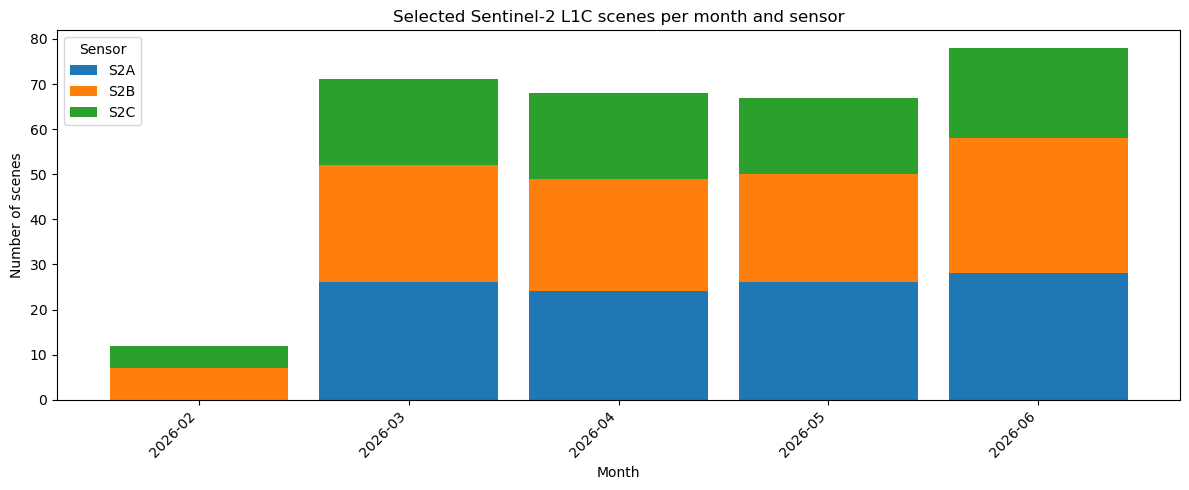

In [17]:
# ---------------------------------------------------------------------
# Plot: number of selected L1C scenes per month and sensor
# ---------------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt

# Ensure date column is datetime
manifest_plot = manifest.copy()
manifest_plot["date"] = pd.to_datetime(manifest_plot["date"])

# Create monthly counts by sensor
monthly_counts = (
    manifest_plot
    .assign(month=manifest_plot["date"].dt.to_period("M").astype(str))
    .groupby(["month", "sensor"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["S2A", "S2B", "S2C"], fill_value=0)
    .sort_index()
)

display(monthly_counts)

# Plot

ax = monthly_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 5),
    width=0.85,
)

ax.set_title("Selected Sentinel-2 L1C scenes per month and sensor")
ax.set_xlabel("Month")
ax.set_ylabel("Number of scenes")
ax.legend(title="Sensor")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. Write the FORCE input queue

The queue contains one retained L1C product path per line followed by `QUEUED`. This is the file passed to `force-level2` in Bash.


In [19]:
# Write the FORCE Level-1 queue file.
# Each line contains the product path followed by its current FORCE status.
with QUEUE_FILE.open("w", encoding="utf-8") as stream:
    for product_path in manifest["path"]:
        stream.write(f"{product_path} QUEUED\n")

print(f"FORCE queue written with {len(manifest)} product(s):")
print(QUEUE_FILE)

print("\nFirst queue entries:")
print(
    "\n".join(
        QUEUE_FILE.read_text(encoding="utf-8").splitlines()[:20]
    )
)

FORCE queue written with 296 product(s):
/mnt/dss_ce/L1/l1_pool_S2.txt

First queue entries:
/mnt/terrabyte_dss/Sentinel-2-Col-1/L1C/tiles/32/U/PU/2026/02/S2B_MSIL1C_20260201T101139_N0511_R022_T32UPU_20260201T141700.SAFE QUEUED
/mnt/terrabyte_dss/Sentinel-2-Col-1/L1C/tiles/33/U/UP/2026/02/S2B_MSIL1C_20260208T100049_N0512_R122_T33UUP_20260208T134006.SAFE QUEUED
/mnt/terrabyte_dss/Sentinel-2-Col-1/L1C/tiles/33/U/UP/2026/02/S2B_MSIL1C_20260208T100049_N0512_R122_T33UUP_20260208T140642.SAFE QUEUED
/mnt/terrabyte_dss/Sentinel-2-Col-1/L1C/tiles/32/U/PU/2026/02/S2B_MSIL1C_20260211T101039_N0512_R022_T32UPU_20260211T152354.SAFE QUEUED
/mnt/terrabyte_dss/Sentinel-2-Col-1/L1C/tiles/33/U/UP/2026/02/S2C_MSIL1C_20260213T100131_N0512_R122_T33UUP_20260213T161658.SAFE QUEUED
/mnt/terrabyte_dss/Sentinel-2-Col-1/L1C/tiles/32/U/QV/2026/02/S2B_MSIL1C_20260224T102019_N0512_R065_T32UQV_20260224T153356.SAFE QUEUED
/mnt/terrabyte_dss/Sentinel-2-Col-1/L1C/tiles/33/U/UQ/2026/02/S2B_MSIL1C_20260224T102019_N0512_R0

## 7. Remove the temporary selected-tile GeoPackage

Run this after the visual check and successful queue creation. Only the temporary GeoPackage is deleted; the `AOI/` directory remains.


In [20]:
if SELECTED_TILES_GPKG.exists():
    SELECTED_TILES_GPKG.unlink()
    print(f"Temporary file removed: {SELECTED_TILES_GPKG}")
else:
    print(f"Temporary file was not present: {SELECTED_TILES_GPKG}")


Temporary file removed: /mnt/dss_ce/PROV/selected_s2_tiles.gpkg
